# Tutorial 03 — Problemas variacionais, espectros e modelos lineares

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 3)
torch.manual_seed(SEED + 3)
OUT = ROOT / "estudos" / "tutorial_03" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 3, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260911 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## Exercício 1

> **Exercise 1 — the projection theorem, numerically.**
> (a) With $V$ spanned by the three functions above and target $g(x,y,z)=z^3$,
> compute $P_V g$ from the normal equations and verify the residual is orthogonal to
> each $\varphi_j$ to within Monte-Carlo error.
>
> (b) Verify $\lVert g\rVert^2 = \lVert P_V g\rVert^2 + \lVert g - P_V g\rVert^2$.
> Which of Lecture 2's error terms does each piece correspond to?

### Resolução

**(a)** O espaço é $V=\operatorname{span}\{1,z,xy\}$, com produto interno para a probabilidade uniforme em $S^2$. Sua matriz de Gram é $\operatorname{diag}(1,1/3,1/15)$. Para $g=z^3$, o vetor de produtos internos é $(0,1/5,0)$; logo
$$P_Vg=\frac35z.$$
O resíduo $z^3-3z/5$ é ortogonal a $1,z,xy$. As equações normais empíricas impõem ortogonalidade no treino até arredondamento; uma amostra independente testa a aproximação do produto interno contínuo.

**(b)** $\|g\|^2=1/7$, $\|P_Vg\|^2=3/25$ e $\|g-P_Vg\|^2=4/175$, portanto $1/7=3/25+4/175$. O resíduo é o erro de aproximação do espaço. A energia da projeção não é um “erro de otimização”; a identidade de Pitágoras sozinha não contém erro estatístico ou computacional. Esses aparecem ao comparar $P_Vg$ à projeção amostral e ao resultado de um algoritmo incompletamente convergido.

In [2]:
X=sphere(100000,3,rng);x,y,z=X.T;F=np.column_stack((np.ones(len(X)),z,x*y));g=z**3
w=np.linalg.solve(F.T@F,F.T@g);res=g-F@w
assert np.max(abs(F.T@res/len(F)))<1e-12
Xv=sphere(100000,3,rng);x,y,z=Xv.T;Fv=np.column_stack((np.ones(len(Xv)),z,x*y));gv=z**3
print('Coeficientes estimados:',w,'| exatos:',[0,.6,0])
print('Ortogonalidade fora do treino:',Fv.T@(gv-Fv@w)/len(Fv))
energy=dict(norm_g=np.mean(gv*gv),norm_projecao=np.mean((.6*z)**2),norm_residuo=np.mean((gv-.6*z)**2))
print(energy);print('Identidade exata:',1/7,3/25+4/175)
assert abs(1/7-3/25-4/175)<1e-15

Coeficientes estimados: [-1.37914016e-03  5.97770014e-01  1.51897123e-04] | exatos: [0, 0.6, 0]
Ortogonalidade fora do treino: [ 2.36466481e-03  5.43955493e-04 -1.03160603e-05]
{'norm_g': np.float64(0.14229927308519114), 'norm_projecao': np.float64(0.11967088848565967), 'norm_residuo': np.float64(0.02286470906548187)}
Identidade exata: 0.14285714285714285 0.14285714285714285


## Exercício 2

> **Exercise 2 — the graph Laplacian is doing geometry.**
> (a) Squash the sphere into an ellipsoid $x^2/a^2+y^2+z^2=1$ with $a=1.4$. The
> $SO(3)$ symmetry breaks, so the $(2\ell+1)$-fold degeneracies must split. Watch
> them split, and identify the residual symmetry protecting those that remain.
>
> (b) Estimate the area of an unknown surface from **Weyl's law**,
> $\lambda_k \sim 4\pi k/\operatorname{Area}(M)$ in dimension 2. Test on $S^2$, where
> the answer is $4\pi$.

### Resolução

**(a)** Para o elipsoide é incorreto reutilizar $2-2X X^T$ como distância quadrática: essa identidade pressupõe vetores unitários. Uso distâncias euclidianas reais e normalização do kernel com $\alpha=1$ para reduzir o efeito da densidade amostral. Sem isso, esticar uma amostra uniforme da esfera muda simultaneamente geometria e densidade e pode produzir um operador com deriva.

O elipsoide $(a,1,1)$ mantém rotações ao redor do eixo $x$ e reflexões. A simetria completa $SO(3)$ é quebrada; os setores de frequência azimutal $\pm m$, $m>0$, ainda dão pares reais seno/cosseno. O modo $m=0$ pode ser simples. O grafo finito não preserva exatamente essas simetrias, portanto as multiplicidades aparecem aproximadamente.

**(b)** Para uma superfície fechada, Weyl prevê $N(\lambda)\sim A\lambda/(4\pi)$, ou $\lambda_k\sim4\pi k/A$. Estimo a inclinação de $\lambda_k$ contra $k$ numa faixa, dando $\hat A=4\pi/\hat s$. Na esfera, verifico primeiro com o espectro analítico $\ell(\ell+1)$ e multiplicidade $2\ell+1$, e depois com o espectro do grafo. Não calibro o grafo usando o valor conhecido de área: isso tornaria o teste circular. Frequências altas demais sofrem viés do kernel e do tamanho da amostra; os primeiros poucos modos também não estão no regime assintótico.

 indice       esfera    elipsoide
      0 1.233937e-15 9.146037e-15
      1 1.999994e+00 1.247628e+00
      2 2.000000e+00 1.769501e+00
      3 2.000005e+00 1.769512e+00
      4 5.759875e+00 3.844854e+00
      5 5.759986e+00 4.352707e+00
      6 5.759987e+00 4.352741e+00
      7 5.760037e+00 5.294261e+00
      8 5.760109e+00 5.294474e+00
      9 1.084735e+01 7.529234e+00
     10 1.084788e+01 7.970426e+00
     11 1.084795e+01 7.970549e+00
     12 1.084800e+01 8.901820e+00
     13 1.084801e+01 8.901986e+00
     14 1.084822e+01 1.020645e+01
     15 1.084856e+01 1.020747e+01
     16 1.672085e+01 1.199820e+01
     17 1.672214e+01 1.236056e+01
     18 1.672252e+01 1.236084e+01
     19 1.672255e+01 1.322454e+01
     20 1.672255e+01 1.322492e+01
     21 1.672257e+01 1.445785e+01


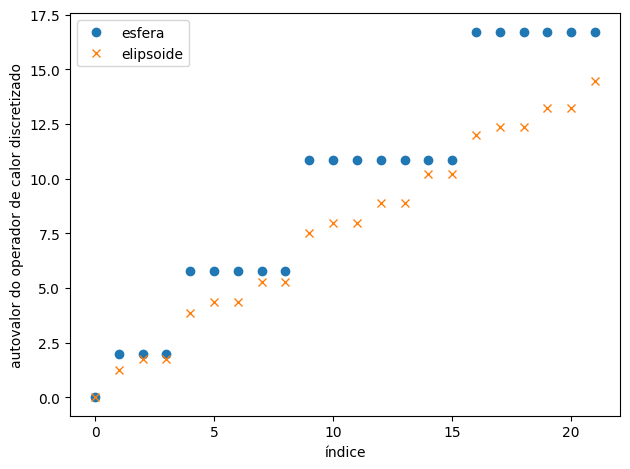

             fonte intervalo  area_estimada  erro_relativo
espectro analítico   100:500      12.550153       0.001291
espectro analítico 1000:5000      12.563974       0.000191
             grafo      5:20      14.589580       0.161002
             grafo     20:50      25.380687       1.019731


In [3]:
def heat_spectrum(X,t=.02,n_eig=70):
    D2=distance.squareform(distance.pdist(X,'sqeuclidean'));W=np.exp(-D2/(4*t))
    # alpha=1: normalização de densidade; manter autoafinidade é deliberado.
    q=W.sum(1);W=W/(q[:,None]*q[None,:]);d=W.sum(1)
    L=(np.eye(len(X))-W/np.sqrt(d[:,None]*d[None,:]))/t
    vals=linalg.eigh(L,subset_by_index=(0,n_eig-1),eigvals_only=True,check_finite=False)
    return np.maximum(vals,0)
X=fibonacci(1800);sphere_spec=heat_spectrum(X);ell_spec=heat_spectrum(X*np.array([1.4,1,1]))
spec_df=table([dict(indice=k,esfera=sphere_spec[k],elipsoide=ell_spec[k]) for k in range(22)],'ex02_espectros',OUT)
plt.figure();plt.plot(spec_df.indice,spec_df.esfera,'o',label='esfera');plt.plot(spec_df.indice,spec_df.elipsoide,'x',label='elipsoide')
plt.xlabel('índice');plt.ylabel('autovalor do operador de calor discretizado');plt.legend();figure('ex02_quebra_simetria',OUT)
exact=np.concatenate([np.full(2*l+1,l*(l+1),float) for l in range(120)])
rows=[]
for name,vals,windows in [('espectro analítico',exact,[(100,500),(1000,5000)]),('grafo',sphere_spec,[(5,20),(20,50)])]:
    for lo,hi in windows:
        slope=np.polyfit(np.arange(lo,hi),vals[lo:hi],1)[0];area=4*np.pi/slope
        rows.append(dict(fonte=name,intervalo=f'{lo}:{hi}',area_estimada=area,erro_relativo=abs(area-4*np.pi)/(4*np.pi)))
weyl_df=table(rows,'ex02_weyl',OUT)

## Exercício 3

> **Exercise 3 — the regulariser encodes a belief, and the basis sets $\kappa$.**
> (a) Penalise $\int(\Delta f)^2$ instead, i.e. $w_k = \lambda_k^2$. Derive and verify
> the new filter. When would you prefer it?
>
> (b) Make the *noise* smooth — built only from harmonics of degree $\le 2$. The
> Dirichlet penalty should lose its advantage. Explain why in one sentence, and say
> what that implies about geometric priors generally.
>
> (c) Run plain gradient descent on both design matrices of §2 with $\eta = 1/\lambda_{\max}$
> and plot loss against iteration. Confirm the rate $(1-1/\kappa)^t$, then apply
> feature standardisation to the monomials and measure how much of the gap it closes.

### Resolução

**(a)** Na base ortonormal de autovetores de $-\Delta$, o funcional $\|f-y\|^2+\lambda\|\Delta f\|^2$ dá, para cada coeficiente,
$$\hat c_k=\frac{c_k^{\mathrm{dados}}}{1+\lambda\lambda_k^2}.$$
A penalização biharmônica suprime frequências altas mais fortemente que Dirichlet. É apropriada quando a suavidade de segunda ordem é uma hipótese justificável; pode apagar sinal genuinamente oscilatório. Em dados amostrais, a fórmula diagonal só é exata se a Gram for identidade; resolvo o sistema completo quando não é.

**(b)** Ruído suave ocupa as mesmas baixas frequências do sinal, de modo que penalizar altas frequências não consegue separá-los. Não há vantagem universal de um prior geométrico: ela depende de onde estão sinal e ruído. O código compara curvas sob ambos os ruídos sem obrigar uma ordenação dos métodos.

**(c)** Para $L(w)=\|Fw-y\|^2/(2N)$, $H=F^TF/N$, $\eta=1/\lambda_{\max}$ e $H\succ0$, a norma do erro contrai por no máximo $(1-1/\kappa)^t$; o excesso de perda tem um limite com expoente $2t$. Não são igualdades para todo estado inicial. Os monômios restritos à esfera são redundantes: removo dependências via QR pivotada antes de falar em $\kappa$ finito. Padronizar escalas não elimina correlações nem toda a má condição.

Erro da identidade do filtro: 0.0


 ruido  penalidade  lambda_  MSE_validacao  MSE_teste
branco       ridge 0.000010       0.118703   0.027007
branco       ridge 0.000023       0.118703   0.027007
branco       ridge 0.000052       0.118703   0.027007
branco       ridge 0.000118       0.118703   0.027006
branco       ridge 0.000268       0.118702   0.027006
branco       ridge 0.000611       0.118702   0.027004
branco       ridge 0.001389       0.118701   0.027001
branco       ridge 0.003162       0.118703   0.027000
branco       ridge 0.007197       0.118727   0.027019
branco       ridge 0.016379       0.118882   0.027173
branco       ridge 0.037276       0.119682   0.028023
branco       ridge 0.084834       0.123246   0.031895
branco       ridge 0.193070       0.136381   0.046260
branco       ridge 0.439397       0.173791   0.087080
branco       ridge 1.000000       0.250929   0.170457
   ...         ...      ...            ...        ...
 suave biharmônico 0.000010       0.180022   0.088495
 suave biharmônico 0.000023 

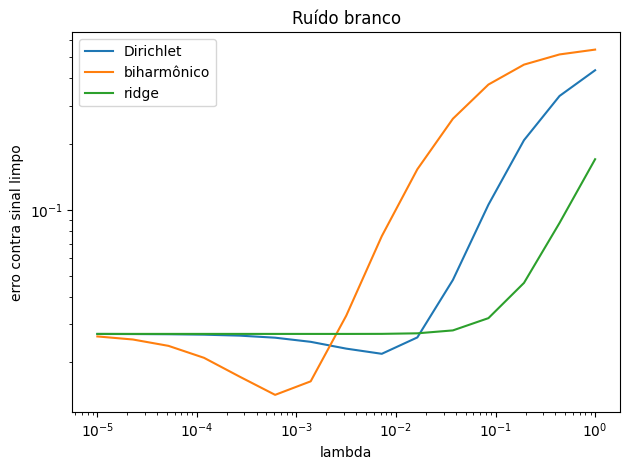

Escolha por validação, ruído branco
 ruido  penalidade  lambda_  MSE_validacao  MSE_teste
branco   Dirichlet 0.007197       0.112666   0.021893
branco biharmônico 0.000611       0.104224   0.014198
branco       ridge 0.001389       0.118701   0.027001


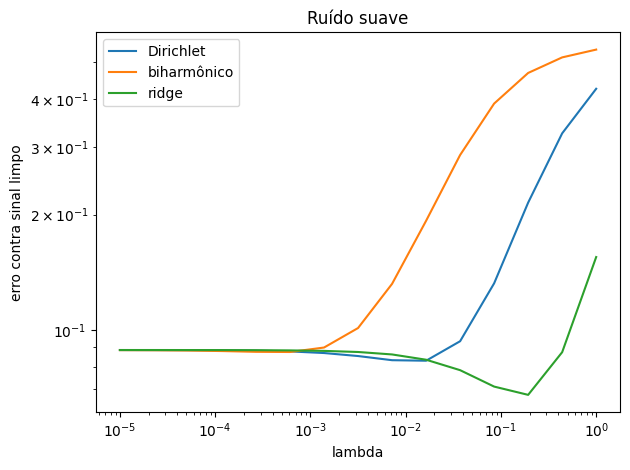

Escolha por validação, ruído suave
ruido  penalidade  lambda_  MSE_validacao  MSE_teste
suave   Dirichlet 0.016379       0.171183   0.083025
suave biharmônico 0.000611       0.178753   0.087498
suave       ridge 0.193070       0.151071   0.067610


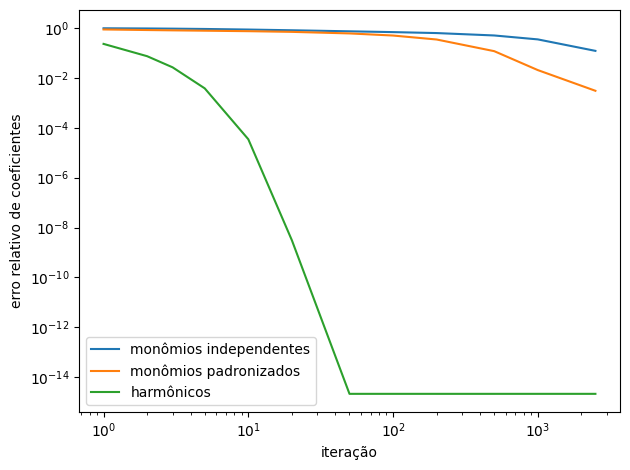

                  base  iteracao  erro_coeficientes  limite_teorico        kappa
monômios independentes         1       9.797956e-01    9.999159e-01 11885.996122
monômios independentes         2       9.619708e-01    9.998317e-01 11885.996122
monômios independentes         3       9.461290e-01    9.997476e-01 11885.996122
monômios independentes         5       9.192823e-01    9.995794e-01 11885.996122
monômios independentes        10       8.713370e-01    9.991590e-01 11885.996122
monômios independentes        20       8.154478e-01    9.983187e-01 11885.996122
monômios independentes        50       7.399213e-01    9.958020e-01 11885.996122
monômios independentes       100       6.878311e-01    9.916217e-01 11885.996122
monômios independentes       200       6.296697e-01    9.833136e-01 11885.996122
monômios independentes       500       5.043873e-01    9.588045e-01 11885.996122
monômios independentes      1000       3.511061e-01    9.193061e-01 11885.996122
monômios independentes      

In [4]:
Xq=fibonacci(6000);Y,ells=real_harmonics(Xq,6,True);lam_e=ells*(ells+1);G=Y.T@Y/len(Y)
beta0=rng.normal(size=Y.shape[1]);lam=.03
c_exact=beta0/(1+lam*lam_e**2)
c_numeric=np.linalg.solve(np.eye(len(beta0))+lam*np.diag(lam_e**2),beta0)
assert np.max(abs(c_numeric-c_exact))<1e-12
print('Erro da identidade do filtro:',np.max(abs(c_numeric-c_exact)))
X=sphere(180,3,rng);Xv=sphere(900,3,rng);Xt=sphere(1600,3,rng)
F=real_harmonics(X,6);Fv=real_harmonics(Xv,6);Ft=real_harmonics(Xt,6)
weights={'ridge':np.where(ells==0,0.,1.),'Dirichlet':lam_e,'biharmônico':lam_e**2};rows=[]
for noise in ['branco','suave']:
    if noise=='branco':err=.3*rng.normal(size=len(X))
    else:
        coeff=rng.normal(size=9);coeff=.3*coeff/np.linalg.norm(coeff);err=F[:,:9]@coeff
    y=target(X)+err;yv=target(Xv)+.3*rng.normal(size=len(Xv))
    for label,pen in weights.items():
        for reg in np.logspace(-5,0,15):
            coef=np.linalg.solve(F.T@F/len(F)+reg*np.diag(pen),F.T@y/len(F))
            rows.append(dict(ruido=noise,penalidade=label,lambda_=reg,MSE_validacao=mean_squared_error(yv,Fv@coef),MSE_teste=mean_squared_error(target(Xt),Ft@coef)))
reg_df=table(rows,'ex03_regularizacao',OUT)
for noise,g in reg_df.groupby('ruido'):
    plt.figure()
    for label,z in g.groupby('penalidade'):plt.loglog(z.lambda_,z.MSE_teste,label=label)
    plt.xlabel('lambda');plt.ylabel('erro contra sinal limpo');plt.title('Ruído '+noise);plt.legend();figure('ex03_'+noise,OUT)
    print('Escolha por validação, ruído',noise)
    print(g.loc[g.groupby('penalidade').MSE_validacao.idxmin()].to_string(index=False))
# Isolar o efeito da base na otimização convexa.
X=sphere(1500,3,rng);M=poly(X,5);_,_,piv=linalg.qr(M,mode='economic',pivoting=True)
M=M[:,piv[:36]];H=real_harmonics(X,5);Z=(M-M.mean(0))/np.where(M.std(0)>1e-12,M.std(0),1)
# A constante foi centrada em zero; recolocá-la evita singularidade artificial.
constant=np.std(M,axis=0)<1e-12;Z[:,constant]=1
rows=[];plt.figure()
for name,Fd in [('monômios independentes',M),('monômios padronizados',Z),('harmônicos',H)]:
    Hess=Fd.T@Fd/len(Fd);ev=linalg.eigvalsh(Hess);kappa=ev[-1]/ev[0];eta=1/ev[-1]
    truth=target(X);wstar=np.linalg.lstsq(Fd,truth,rcond=None)[0];w=np.zeros(len(wstar));hist=[]
    for it in range(2500):
        w-=eta*(Fd.T@(Fd@w-truth)/len(Fd))
        if it in [0,1,2,4,9,19,49,99,199,499,999,2499]:
            e=np.linalg.norm(w-wstar)/np.linalg.norm(wstar);bound=(1-1/kappa)**(it+1)
            hist.append((it+1,e));rows.append(dict(base=name,iteracao=it+1,erro_coeficientes=e,limite_teorico=bound,kappa=kappa))
    h=np.array(hist);plt.loglog(h[:,0],np.maximum(h[:,1],1e-15),label=name)
plt.xlabel('iteração');plt.ylabel('erro relativo de coeficientes');plt.legend();figure('ex03_condicionamento',OUT)
condition_df=table(rows,'ex03_gradiente',OUT)

## Exercício 4

> **Exercise 4 — how much does invariance buy?**
> (a) A linear model on raw coefficients cannot represent the area; a *quadratic* one
> can, since $a_k^2, b_k^2$ are among its features. Fit it. How many features does it
> use, how many does it need, and what happens to the rest?
>
> (b) Train the quadratic raw model on curves in a fixed orientation and test on
> randomly rotated ones; then repeat with rotation augmentation. Compare both against
> the invariant model, which needs neither.
>
> (c) Relate what you find to Tutorial 2 Exercise 5. What is the analogue here of
> splitting by orbit rather than by sample?

### Resolução

**(a)** Com oito modos há 16 coeficientes brutos. Todos os monômios até grau 2 dão $\binom{18}{2}=153$ colunas (incluindo constante), mas a área é
$$A=\pi+\frac\pi2\sum_{k=1}^8(a_k^2+b_k^2).$$
Ela precisa apenas de 16 quadrados mais a constante nessa escrita; usando invariantes, de oito $p_k=a_k^2+b_k^2$ mais a constante. Na representação quadrática completa e de posto completo, os coeficientes desnecessários devem tender a zero. Colunas redundantes ou dados subdeterminados tornam a decomposição em pesos não identificável.

**(b)** “Orientação fixa” precisa ser especificada: coeficientes gaussianos independentes de mesma variância já produzem uma distribuição invariante a rotações. Para um teste genuíno, gero uma família com $b_k=0$ e faço o treino nessa orientação. O modelo quadrático não observa os termos $b_k^2$; ao rotacionar no teste, eles passam a variar e o erro pode crescer. Rotação aumentada fornece esses exemplos; a representação por $p_k$ já impõe a simetria.

**(c)** Cada curva-base e todas as suas rotações devem ficar na mesma partição. Primeiro separo as curvas-base; somente depois aumento o treino. Caso contrário, avaliar uma rotação da mesma curva responde a uma pergunta mais fácil do que generalizar para formas novas.

In [5]:
D=curves(2600,rng);raw=np.column_stack((D['a'],D['b']))
quad=PolynomialFeatures(2,include_bias=True);F=quad.fit_transform(raw);w=np.linalg.lstsq(F,D['area'],rcond=None)[0]
necessary=(quad.powers_==2).sum(1)==1;necessary &= (quad.powers_.sum(1)==2)
other=(quad.powers_.sum(1)>0)&(~necessary)
print('Colunas:',F.shape[1],'quadrados:',necessary.sum(),'maior peso desnecessário:',abs(w[other]).max())
assert np.max(abs(F@w-D['area']))<1e-9
# Curvas-base não rotacionadas, distintas no treino e no teste.
a=rng.normal(size=(1200,8))*.16/np.arange(1,9)**1.6;bb=np.zeros_like(a)
y=np.pi+.5*np.pi*np.sum(a*a,axis=1);tr=np.arange(800);te=np.arange(800,1200)
k=np.arange(1,9)
def rotate(a,b,ang):
    ang=np.asarray(ang).reshape(-1,1)*k
    return a*np.cos(ang)-b*np.sin(ang),a*np.sin(ang)+b*np.cos(ang)
ar,br=rotate(a[te],bb[te],rng.uniform(0,2*np.pi,len(te)))
rows=[]
for aug in [False,True]:
    at=a[tr];bt=bb[tr];yt=y[tr]
    if aug:
        at=np.repeat(at,8,axis=0);bt=np.repeat(bt,8,axis=0);yt=np.repeat(yt,8)
        at,bt=rotate(at,bt,rng.uniform(0,2*np.pi,len(at)))
    Ft=quad.transform(np.column_stack((at,bt)));coef=np.linalg.lstsq(Ft,yt,rcond=None)[0]
    pred=quad.transform(np.column_stack((ar,br)))@coef
    rows.append(dict(modelo='quadrático'+(' aumentado' if aug else ' fixo'),MSE=mean_squared_error(y[te],pred)))
Fi=np.column_stack((np.ones(len(tr)),a[tr]**2));wi=np.linalg.lstsq(Fi,y[tr],rcond=None)[0]
yp=np.column_stack((np.ones(len(te)),ar*ar+br*br))@wi
rows.append(dict(modelo='invariante',MSE=mean_squared_error(y[te],yp)))
invariance_df=table(rows,'ex04_rotacoes',OUT)

Colunas: 153 quadrados: 16 maior peso desnecessário: 1.3704828938365665e-11
              modelo          MSE
     quadrático fixo 2.568336e-03
quadrático aumentado 1.799688e-28
          invariante 2.650573e-30


## Exercício 5

> **Exercise 5 — better features, and honest regularisation.**
> (a) Convexity is governed by $r^2+2r'^2-rr''$, whose $r''$ term weights mode $k$ by
> $k^2$. Add the features $k^2p_k$ and $k^4p_k$ and measure the gain. Which weighting
> matters most, and would you have guessed it?
>
> (b) Repeat the path with ridge and overlay the two. Confirm that ridge shrinks
> everything and zeroes nothing, and explain it from the geometry of the two balls.
>
> (c) Add a near-duplicate of $\sum_k k^2p_k$. Which does lasso choose, and how stable
> is the choice across bootstrap resamples? Show that the elastic net stabilises it.

### Resolução

**(a)** Atenção: adicionar individualmente $k^2p_k$ e $k^4p_k$ a uma regressão linear que já contém cada $p_k$ **não expande o espaço**; cada nova coluna é múltipla de uma existente. Com padronização e penalização, pode mudar a norma efetiva; isso não é nova informação. As somas ponderadas também são combinações lineares, embora possam facilitar uma regularização parcimoniosa. Testo separadamente “duplicação reescalada” e modelos compactos só com a soma, usando validação. O peso $k^4$ é plausível para a variância de $r''$, mas convexidade depende ainda de fases e interações em $r^2+2(r')^2-rr''$; o espectro de potências não determina toda a curva.

**(b)** Para comparar caminhos, lasso minimiza $\|Fw-y\|^2/(2N)+\alpha\|w\|_1$ e ridge $\|Fw-y\|^2/(2N)+\alpha\|w\|^2/2$. As quinas da bola $\ell_1$ favorecem coordenadas exatamente nulas. A bola $\ell_2$ suaviza continuamente os pesos; genericamente não zera, mas zeros exatos são possíveis por simetria ou correlação exatamente nula — “nunca zera” não é um teorema literal.

**(c)** Colunas quase duplicadas tornam a seleção lasso instável. A penalização quadrática do elastic net favorece distribuir pesos entre colunas correlacionadas. Mostro a distribuição dos dois coeficientes em 35 bootstraps; estabilidade é uma propriedade empírica do ajuste escolhido, não garantia automática para qualquer hiperparâmetro.

         features  posto   C  acuracia_validacao  acuracia_teste
              p_k      8 0.1             0.82125         0.79625
p_k e duplicações      8 0.1             0.81875         0.79750
           soma p      1 0.1             0.77875         0.77125
         soma k²p      1 0.1             0.79625         0.78500
         soma k⁴p      1 0.1             0.79375         0.78375


/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.848e-04, tolerance: 1.030e-05
  model = cd_fast.enet_coordinate_descent(


modelo    alpha  nao_nulos  MSE_validacao
 lasso 0.000100         15       0.000349
 ridge 0.000100         18       0.000349
 lasso 0.000165         10       0.000350
 ridge 0.000165         18       0.000349
 lasso 0.000272          8       0.000351
 ridge 0.000272         18       0.000349
 lasso 0.000450          6       0.000352
 ridge 0.000450         18       0.000349
 lasso 0.000742          2       0.000353
 ridge 0.000742         18       0.000349
 lasso 0.001225          2       0.000355
 ridge 0.001225         18       0.000349
 lasso 0.002022          2       0.000358
 ridge 0.002022         18       0.000350
 lasso 0.003338          2       0.000367
   ...      ...        ...            ...
 ridge 0.015013         18       0.000359
 lasso 0.024781          2       0.000949
 ridge 0.024781         18       0.000368
 lasso 0.040904          1       0.001934
 ridge 0.040904         18       0.000384
 lasso 0.067517          1       0.004587
 ridge 0.067517         18       0

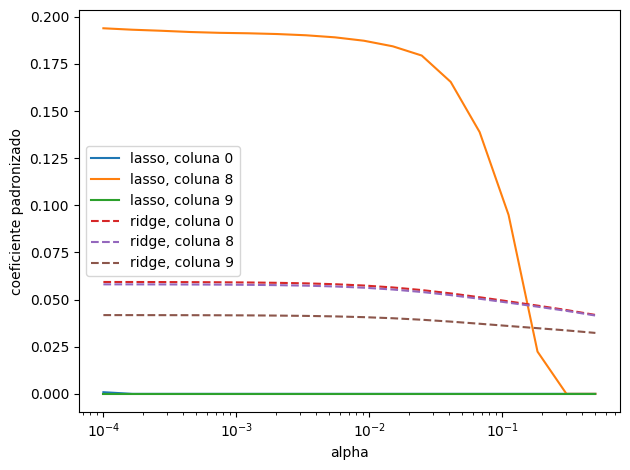

 repeticao      modelo  peso_original  peso_duplicata
         0       lasso       0.186546        0.000000
         0 elastic net       0.074726        0.073167
         1       lasso       0.178485        0.015866
         1 elastic net       0.075710        0.075018
         2       lasso       0.171492        0.025052
         2 elastic net       0.076117        0.075595
         3       lasso       0.194038        0.000000
         3 elastic net       0.076026        0.074326
         4       lasso       0.205179        0.000000
         4 elastic net       0.078480        0.077368
         5       lasso       0.197338        0.000000
         5 elastic net       0.076572        0.075000
         6       lasso       0.194642        0.000000
         6 elastic net       0.075939        0.074997
         7       lasso       0.192175        0.000000
       ...         ...            ...             ...
        27 elastic net       0.074282        0.073441
        28       lasso      

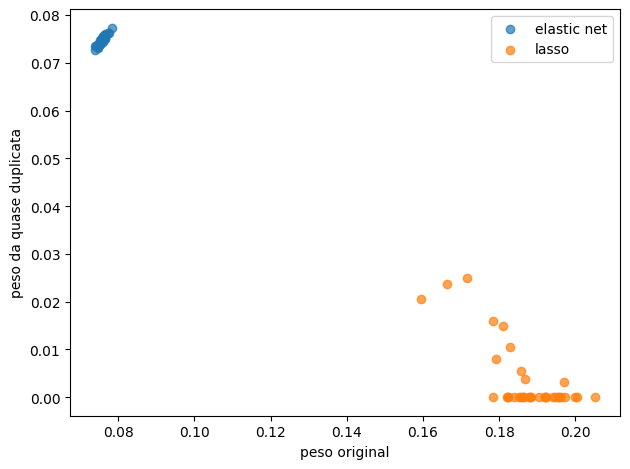

In [6]:
from sklearn.linear_model import Lasso,ElasticNet
from sklearn.model_selection import train_test_split
D=curves(4000,rng);P=D['P'];k=D['k'];y=D['convex']
tr,rest=train_test_split(np.arange(len(P)),test_size=.4,random_state=1,stratify=y)
va,te=train_test_split(rest,test_size=.5,random_state=2,stratify=y[rest])
sets={'p_k':P,'p_k e duplicações':np.column_stack((P,P*k*k,P*k**4)),
      'soma p':P.sum(1)[:,None],'soma k²p':(P*k*k).sum(1)[:,None],'soma k⁴p':(P*k**4).sum(1)[:,None]}
rows=[]
for name,F in sets.items():
    options=[]
    for C in [.1,1,10,100]:
        m=make_pipeline(StandardScaler(),LogisticRegression(C=C,max_iter=3000)).fit(F[tr],y[tr])
        options.append((accuracy_score(y[va],m.predict(F[va])),m,C))
    acc,m,C=max(options,key=lambda z:z[0])
    rows.append(dict(features=name,posto=np.linalg.matrix_rank(F),C=C,acuracia_validacao=acc,acuracia_teste=accuracy_score(y[te],m.predict(F[te]))))
feature_df=table(rows,'ex05_convexidade',OUT)
F=np.column_stack((P,(P*k*k).sum(1),(P*k**4).sum(1),P.sum(1),np.sqrt(P.sum(1)),rng.normal(size=(len(P),6))))
scaler=StandardScaler().fit(F[tr]);Z=scaler.transform(F);length=D['length'];yc=length[tr]-length[tr].mean()
rows=[];paths={'lasso':[],'ridge':[]};alphas=np.logspace(-4,-.3,18)
for alpha in alphas:
    for name,model in [('lasso',Lasso(alpha=alpha,max_iter=40000,tol=1e-7)),('ridge',Ridge(alpha=len(tr)*alpha))]:
        model.fit(Z[tr],length[tr]);paths[name].append(model.coef_)
        rows.append(dict(modelo=name,alpha=alpha,nao_nulos=int((abs(model.coef_)>1e-9).sum()),MSE_validacao=mean_squared_error(length[va],model.predict(Z[va]))))
path_df=table(rows,'ex05_caminhos',OUT)
plt.figure()
for name,path in paths.items():
    a=np.array(path)
    for j in [0,8,9]:plt.semilogx(alphas,a[:,j],linestyle='-' if name=='lasso' else '--',label=f'{name}, coluna {j}')
plt.xlabel('alpha');plt.ylabel('coeficiente padronizado');plt.legend();figure('ex05_caminhos',OUT)
base=(P*k*k).sum(1);Fdup=np.column_stack((base,base+.015*base.std()*rng.normal(size=len(base)),P.sum(1),rng.normal(size=len(base))))
Zdup=StandardScaler().fit(Fdup[tr]).transform(Fdup)
rows=[]
for rep in range(35):
    ids=rng.choice(tr,len(tr),replace=True)
    for name,m in [('lasso',Lasso(alpha=.002,max_iter=50000,tol=1e-7)),('elastic net',ElasticNet(alpha=.02,l1_ratio=.1,max_iter=50000,tol=1e-7))]:
        m.fit(Zdup[ids],length[ids]);rows.append(dict(repeticao=rep,modelo=name,peso_original=m.coef_[0],peso_duplicata=m.coef_[1]))
boot_df=table(rows,'ex05_bootstrap',OUT)
print('Desvios dos coeficientes por bootstrap:');print(boot_df.groupby('modelo')[['peso_original','peso_duplicata']].std().to_string())
plt.figure()
for name,g in boot_df.groupby('modelo'):plt.scatter(g.peso_original,g.peso_duplicata,label=name,alpha=.7)
plt.xlabel('peso original');plt.ylabel('peso da quase duplicata');plt.legend();figure('ex05_estabilidade',OUT)

## Exercício 6

> **Exercise 6 — the condition number, in training curves.**
> (a) Swap Adam for `torch.optim.SGD` and find the largest stable learning rate.
> Compare epochs-to-target with raw and with standardised features, and relate the
> ratio to the $\kappa$ values of §6.
>
> (b) Add `weight_decay` and confirm it reproduces the ridge solution of §7 for the
> corresponding $\lambda$.
>
> (c) Rewrite §7's logistic regression in PyTorch with `BCEWithLogitsLoss` and check
> it matches your hand-written gradient descent. Why is that loss preferred to a
> sigmoid followed by a plain cross-entropy?

### Resolução

**(a)** Uso SGD full-batch sem momentum, que coincide com gradiente descendente. Para `MSELoss` média, $H=2F^TF/N$ e a condição de estabilidade é $0<\eta<2/\lambda_{\max}(H)$. O valor-limite não é geralmente estável no sentido de convergir. Reporto a maior taxa estável entre as testadas e épocas para reduzir o excesso de perda; casos que não atingem a meta são registrados, não inventados. O pior caso depende de $\kappa$; a taxa observada também depende do alvo e da projeção do erro inicial nas direções espectrais.

**(b)** Se o objetivo é MSE $+\lambda\|w\|^2$, então o gradiente extra é $2\lambda w$. Com SGD, `weight_decay=2*lambda` reproduz isso. Não penalizo o intercepto. Comparo ao sistema $(F^TF/N+\lambda D)w=F^Ty/N$, $D=\operatorname{diag}(0,1,\ldots,1)$. Não transporto a equivalência automaticamente para AdamW, que usa outro mecanismo.

**(c)** A logística usa $\log(1+e^z)-yz$; na forma estável, $\max(z,0)-yz+\log(1+e^{-|z|})$. `BCEWithLogitsLoss` recebe logits, combina sigmoid e entropia cruzada e evita logaritmos de probabilidades arredondadas para zero. Com inicialização, passos e precisão iguais, PyTorch e o gradiente manual coincidem. Fonte de implementação: documentação PyTorch 2.10, seção BCEWithLogitsLoss (REFERENCIAS.md).

In [7]:
D=curves(1600,rng);P=D['P'];y=D['area'];Z=StandardScaler().fit_transform(P)
rows=[]
for name,F0 in [('bruto',P),('padronizado',Z)]:
    F=np.column_stack((np.ones(len(P)),F0));H=2*F.T@F/len(F);ev=linalg.eigvalsh(H);critical=2/ev[-1]
    optw=np.linalg.lstsq(F,y,rcond=None)[0];target_loss=1e-8
    for factor in [.25,.8,.99,1.01]:
        eta=critical*factor;Xt=torch.tensor(F,dtype=torch.float64);yt=torch.tensor(y,dtype=torch.float64)
        w=torch.nn.Parameter(torch.zeros(F.shape[1],dtype=torch.float64));opt=torch.optim.SGD([w],lr=eta)
        epochs_hit=None;last=float('inf')
        for ep in range(4000):
            opt.zero_grad();loss=torch.mean((Xt@w-yt)**2)
            if not torch.isfinite(loss) or loss>1e15:break
            loss.backward();opt.step();last=float(loss.detach())
            if last<target_loss and epochs_hit is None:epochs_hit=ep+1
        rows.append(dict(features=name,fator_limite=factor,taxa=eta,estavel_teoricamente=factor<1,kappa=ev[-1]/ev[0],epocas_ate_MSE_1e8=epochs_hit,MSE_final=last))
sgd_df=table(rows,'ex06_sgd',OUT)
F=np.column_stack((np.ones(len(Z)),Z));lam=.05;Dpen=np.diag(np.r_[0.,np.ones(Z.shape[1])])
closed=np.linalg.solve(F.T@F/len(F)+lam*Dpen,F.T@y/len(F))
model=nn.Linear(Z.shape[1],1,dtype=torch.float64)
with torch.no_grad():model.weight.zero_();model.bias.zero_()
opt=torch.optim.SGD([{'params':model.weight,'weight_decay':2*lam},{'params':model.bias,'weight_decay':0}],lr=.1)
Xt=torch.tensor(Z,dtype=torch.float64);yt=torch.tensor(y,dtype=torch.float64).reshape(-1,1)
for _ in range(1500):
    opt.zero_grad();loss=nn.functional.mse_loss(model(Xt),yt);loss.backward();opt.step()
tw=np.r_[model.bias.detach().numpy(),model.weight.detach().numpy().ravel()]
print('SGD weight_decay contra ridge:',np.max(abs(tw-closed)));assert np.max(abs(tw-closed))<1e-8
# Logística: mesmo dado, gradiente e precisão.
yc=D['convex'];theta=np.zeros(F.shape[1]);eta=.2
w=torch.nn.Parameter(torch.zeros(F.shape[1],dtype=torch.float64));opt=torch.optim.SGD([w],lr=eta)
Ft=torch.tensor(F,dtype=torch.float64);ytc=torch.tensor(yc,dtype=torch.float64)
from scipy.special import expit
for _ in range(1200):
    theta-=eta*(F.T@(expit(F@theta)-yc)/len(F))
    opt.zero_grad();loss=nn.functional.binary_cross_entropy_with_logits(Ft@w,ytc);loss.backward();opt.step()
logistic_error=np.max(abs(theta-w.detach().numpy()))
print('Diferença manual/PyTorch:',logistic_error);assert logistic_error<1e-10
print('Loss com logits extremos:',nn.functional.binary_cross_entropy_with_logits(torch.tensor([-1000.,1000.]),torch.tensor([1.,0.])).item())
write_summary(OUT.parent/'README.md','ligar projeção, espectro e regularização aos modelos lineares.',
'o espaço de funções, a norma penalizada e a base têm papéis distintos.',
'foram resolvidos seis exercícios com projeção exata, Laplacianos, curvas polares e otimização.',
f"a projeção é 3z/5; SGD e a solução ridge coincidiram numericamente; logística manual/PyTorch diferiu {logistic_error:.1e}.",
'colunas reescaladas não acrescentam informação; Weyl no grafo sofre viés de discretização; as conclusões dependem do regime amostral.')

   features  fator_limite     taxa  estavel_teoricamente        kappa  epocas_ate_MSE_1e8    MSE_final
      bruto          0.25 0.245849                  True 6.990536e+10                 NaN 3.780992e-05
      bruto          0.80 0.786718                  True 6.990536e+10                 NaN 3.286317e-05
      bruto          0.99 0.973563                  True 6.990536e+10                 NaN 3.131202e-05
      bruto          1.01 0.993231                 False 6.990536e+10                 NaN 9.626921e+14
padronizado          0.25 0.224290                  True 1.240850e+00                19.0 2.078155e-31
padronizado          0.80 0.717729                  True 1.240850e+00                15.0 9.071900e-32
padronizado          0.99 0.888189                  True 1.240850e+00               344.0 3.170235e-31
padronizado          1.01 0.906133                 False 1.240850e+00                 NaN 9.660722e+14


SGD weight_decay contra ridge: 1.7763568394002505e-15


Diferença manual/PyTorch: 5.551115123125783e-17
Loss com logits extremos: 1000.0
